## Import Libraries


In [7]:
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait as WDW
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager

### Setup and Configure Selenium WebDriver

In [13]:
print("Configuring Webdriver...")
chrome_opt = Options() # initialize the chrome webdriver 
chrome_opt.add_argument("--headless=new") # run in headless mode (new syntax for Chrome 109+)
chrome_opt.add_argument("--disable-gpu") # disable gpu acceleration
chrome_opt.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36") # set user agent to avoid detection
print("Configuration done!")

Configuring Webdriver...
Configuration done!


In [15]:
# Setting up the webdriver: Installation and Initialization
print("Installing Chrome Webdriver...")
service = Service(ChromeDriverManager().install())
print("Final Setup")
driver = webdriver.Chrome(service=service, options=chrome_opt)
print("done!!")

Installing Chrome Webdriver...
Final Setup
done!!


## Making a connection to the webpage

In [16]:
URL = "https://www.glasses.com/gl-us/eyeglasses"

In [17]:
print(f"Visiting {URL}...")
driver.get(URL)

# Further Instructions
try:
    print("Waiting for the product tiles to load...")
    WDW(driver, 10).until(EC.presence_of_element_located((By.
    CLASS_NAME, "catalog-page")))
    print("Done, Proceed!")
except TimeoutError as e:
    print(f"Expected tag did not load on time: {e}")
    pass

Visiting https://www.glasses.com/gl-us/eyeglasses...
Waiting for the product tiles to load...
Done, Proceed!


In [19]:
content = driver.page_source
page = BeautifulSoup(content, "html.parser")

<html xmlns:wairole="http://www.w3.org/2005/01/wai-rdf/GUIRoleTaxonomy#" xmlns:waistate="http://www.w3.org/2005/07/aaa" lang="en" xml:lang="en"><head><script type="text/javascript" async="" charset="utf-8" id="utag_160" src="//media.glasses.com/utilities/repoUtilities/monetate/glasses.js"></script><script src="https://dkpklk99llpj0.cloudfront.net/r12f1knh_1743153372003.js"></script><script src="https://am.freshrelevance.com/v/?w=r12f1knh"></script><title>Stylish Prescription Eyeglasses and Frames | Glasses.com®</title><meta name="description" content="Shop stylish Prescription Eyeglasses and Glasses Frames at Glasses.com. Find affordable designs, top brands, &amp; up to 50% off lenses perfect for every look!"><link rel="canonical" href="https://www.glasses.com/gl-us/eyeglasses"><meta name="keyword" content="Prescription Eyeglasses and Frames glasses, Prescription Eyeglasses and Frames sunglasses, Prescription Eyeglasses and Frames eyeglasses, Prescription Eyeglasses and Frames eyewear,
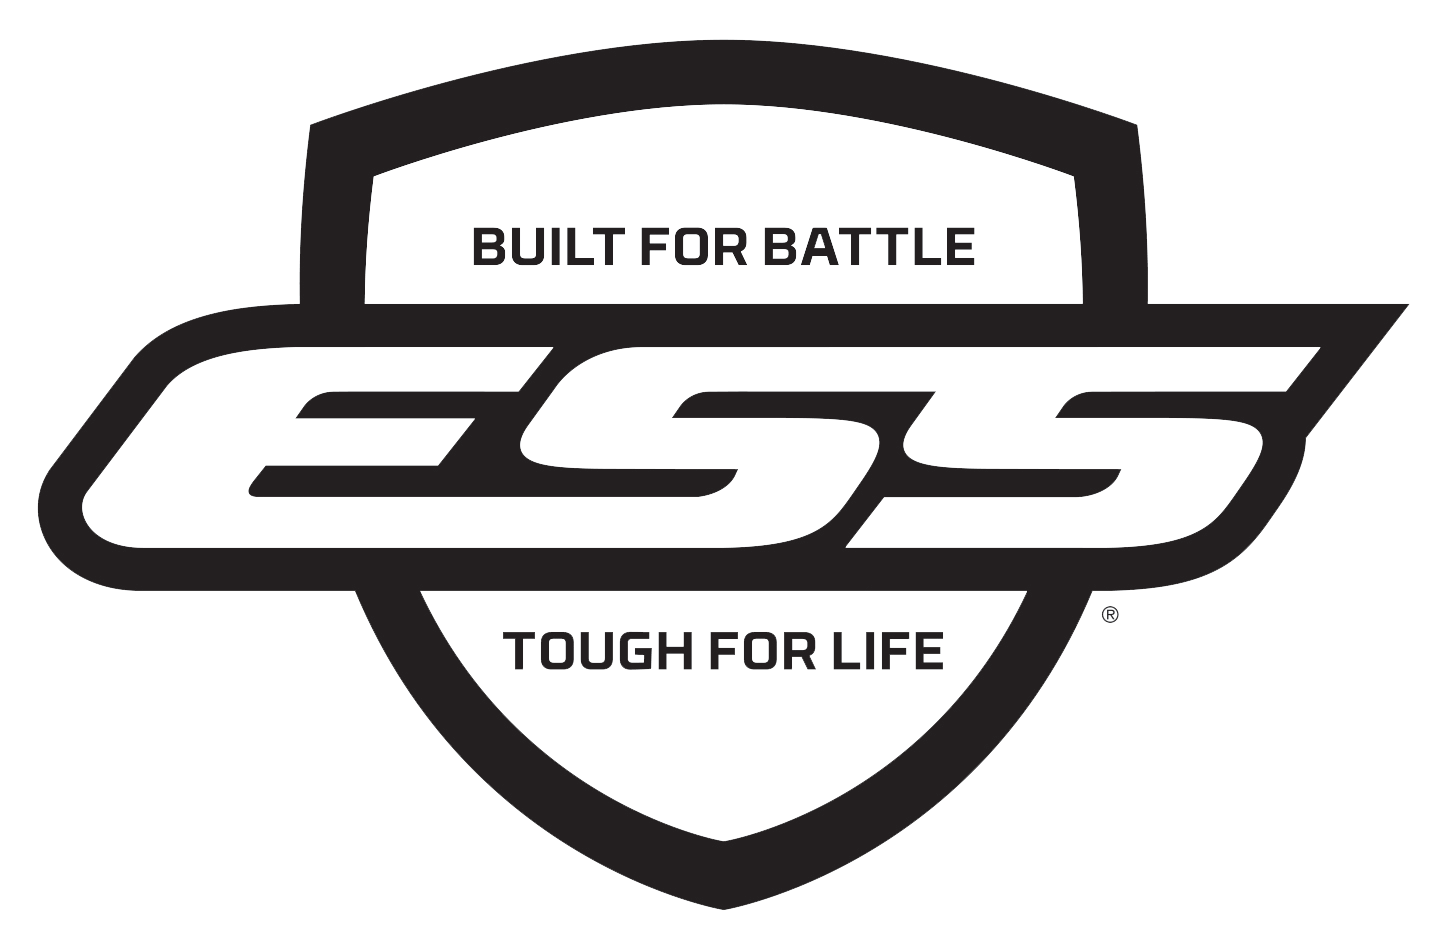
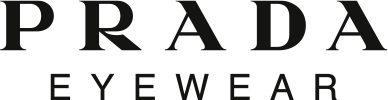
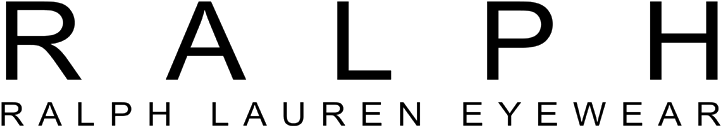
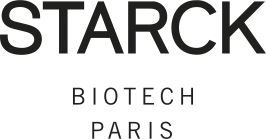

In [21]:
print(content)

<html lang="en" xml:lang="en" xmlns:wairole="http://www.w3.org/2005/01/wai-rdf/GUIRoleTaxonomy#" xmlns:waistate="http://www.w3.org/2005/07/aaa"><head><script async="" charset="utf-8" id="utag_160" src="//media.glasses.com/utilities/repoUtilities/monetate/glasses.js" type="text/javascript"></script><script src="https://dkpklk99llpj0.cloudfront.net/r12f1knh_1743153372003.js"></script><script src="https://am.freshrelevance.com/v/?w=r12f1knh"></script><title>Stylish Prescription Eyeglasses and Frames | Glasses.com®</title><meta content="Shop stylish Prescription Eyeglasses and Glasses Frames at Glasses.com. Find affordable designs, top brands, &amp; up to 50% off lenses perfect for every look!" name="description"/><link href="https://www.glasses.com/gl-us/eyeglasses" rel="canonical"/><meta content="Prescription Eyeglasses and Frames glasses, Prescription Eyeglasses and Frames sunglasses, Prescription Eyeglasses and Frames eyeglasses, Prescription Eyeglasses and Frames eyewear, Prescription
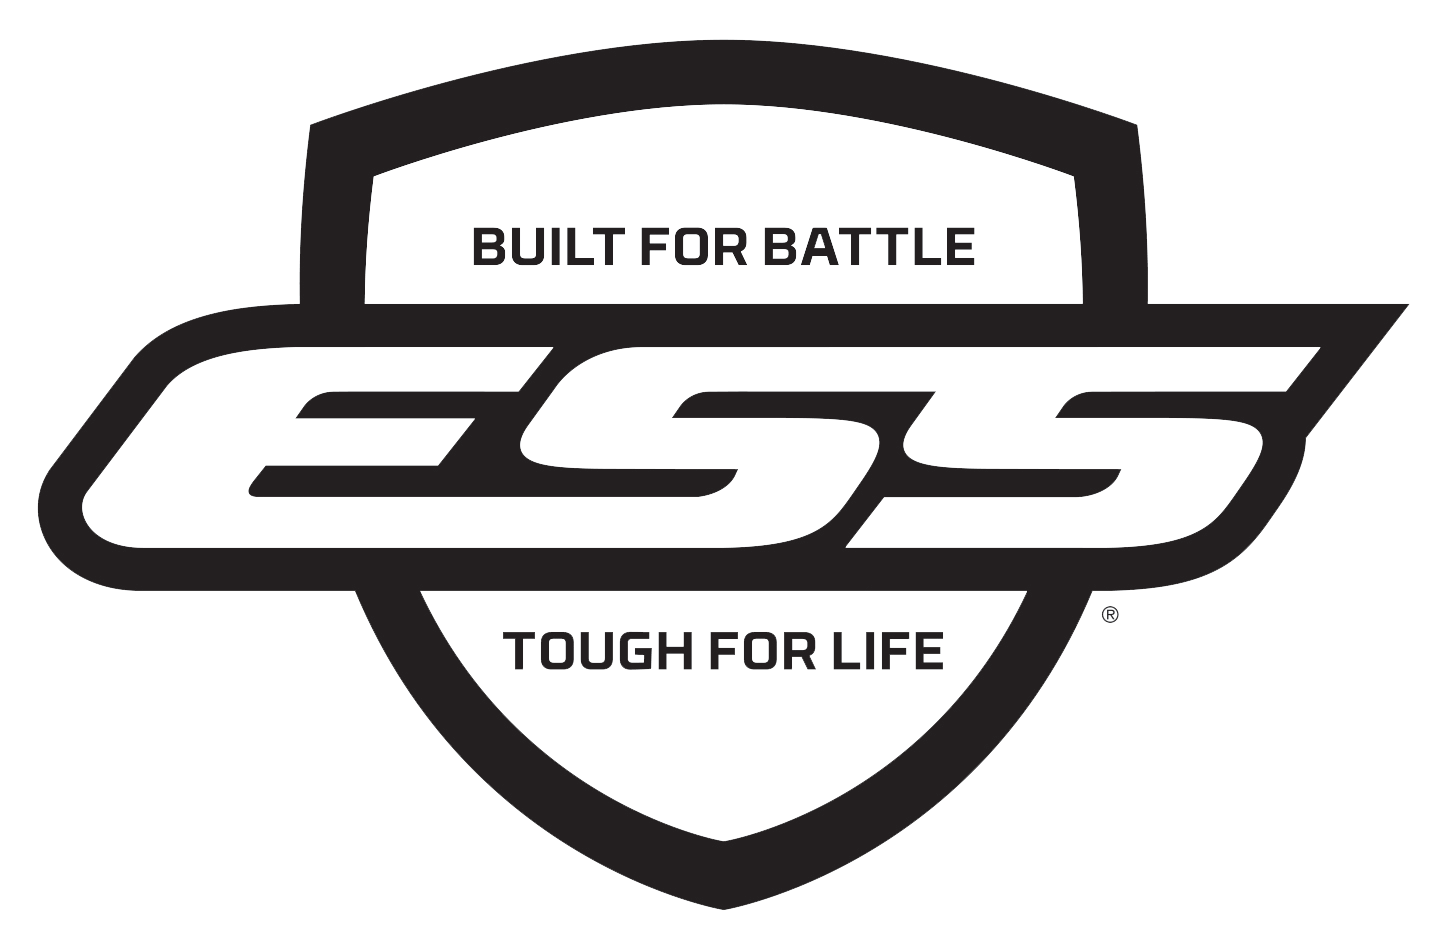
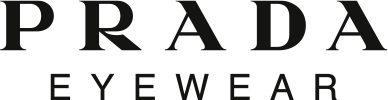
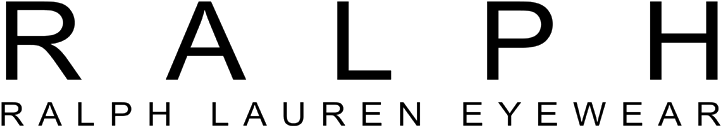
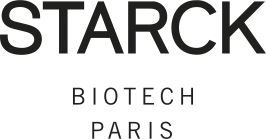

In [20]:
print(page)

### Data Extraction

In [22]:
product_tiles = page.find_all("a", class_="product-tile")
print(f"Found {len(product_tiles)} product tiles on the page.")

Found 26 product tiles on the page.


In [ ]:
for tile in product_tiles:
    product_info = tile.find("div", class_="product-info")

    if product_info:
        name_tag = product_info.find("div", class_="product-code")
        name = name_tag.text if name_tag else "Unknown"

        #brand
        brand_tag = product_info.find("div", class_="product-brand")
        brand = brand_tag.text if brand_tag else "Unknown"
        #price
        price_container = product_info.find("div", class_="product-prices-container")
        if price_container:
            #formmer price
            former_price_tag = price_container.find("div", class_="product-list-price")
            former_price = former_price_tag.text if former_price_tag else "Unknown"
            #current price
            current_price_tag = price_container.find("div", class_="product-offer-price")
            current_price = current_price_tag.text if current_price_tag else "Unknown"
        else:
            former_price = current_price = "Unknown"
    else:
        name = brand = former_price = current_price = "Unknown"

    data = {
        "Product Name": name,
        "Brand": brand,
        "Former_Price": former_price,
        "Current_Price": current_price
    }   
    print(data)
    products

{'Product Name': 'DG3404', 'Brand': 'Dolce & Gabbana', 'Former_Price': '422.00', 'Current_Price': '295.40'}
{'Product Name': 'MK3068 Portland', 'Brand': 'Michael Kors', 'Former_Price': '175.00', 'Current_Price': '87.50'}
{'Product Name': 'PH2283U', 'Brand': 'Polo Ralph Lauren', 'Former_Price': '237.00', 'Current_Price': '165.90'}
{'Product Name': 'VE1302', 'Brand': 'Versace', 'Former_Price': '526.00', 'Current_Price': '368.20'}
{'Product Name': 'RB7021 Matthew', 'Brand': 'Ray-Ban', 'Former_Price': '176.00', 'Current_Price': '88.00'}
{'Product Name': 'VO5615', 'Brand': 'Vogue Eyewear', 'Former_Price': '128.00', 'Current_Price': '89.60'}
{'Product Name': 'JC3025', 'Brand': 'Jimmy Choo', 'Former_Price': '287.00', 'Current_Price': '200.90'}
{'Product Name': 'FZ8020U', 'Brand': 'Scuderia Ferrari', 'Former_Price': '191.00', 'Current_Price': '133.70'}
{'Product Name': 'PH2251U', 'Brand': 'Polo Ralph Lauren', 'Former_Price': '183.00', 'Current_Price': '91.50'}
{'Product Name': 'JB2005 Kids', '